# Experiment 3A: Memorization of Random Labels

### Objective
To investigate whether an overparameterized neural network can memorize randomly assigned training labels.

The experiment compares training on normal MNIST labels with training on randomly assigned labels.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import numpy as np


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
WIDTH = 2048
EPOCHS = 30
BATCH_SIZE = 128
LEARNING_RATE = 0.01

print("\nExperiment settings:")
print("Width:", WIDTH)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)


Experiment settings:
Width: 2048
Epochs: 30
Batch size: 128
Learning rate: 0.01


In [ ]:
transform = transforms.ToTensor()

### Experimental Configuration

- Dataset: MNIST
- Width: 2048
- Parameters: 10,020,874
- Optimizer: SGD
- Learning rate: 0.01
- Batch size: 128
- Epochs: 30
- Labels: Normal vs Random

In [ ]:
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nTraining samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Training samples: 60000
Test samples: 10000


In [ ]:
class RandomLabelDataset(Dataset):

    def __init__(self, dataset, seed=42):

        self.dataset = dataset

        generator = torch.Generator()
        generator.manual_seed(seed)

        # Generate completely random labels from 0 to 9
        self.random_labels = torch.randint(
            low=0,
            high=10,
            size=(len(dataset),),
            generator=generator
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):

        image, _ = self.dataset[index]

        # Ignore the original label
        # Return the random label instead
        return image, self.random_labels[index]


random_train_dataset = RandomLabelDataset(
    train_dataset,
    seed=SEED
)

random_train_loader = DataLoader(
    random_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)


In [ ]:
class MLP(nn.Module):

    def __init__(self, width):

        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, width),
            nn.ReLU(),

            nn.Linear(width, 10)
        )

    def forward(self, x):

        return self.network(x)

In [ ]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


In [ ]:
def train_model(model, train_loader, test_loader, experiment_name):

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LEARNING_RATE
    )

    history = []

    print("\n" + "=" * 70)
    print("EXPERIMENT:", experiment_name)
    print("=" * 70)

    print("Parameters:", count_parameters(model))

    start_time = time.time()

    for epoch in range(EPOCHS):

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

        train_loss = running_loss / total
        train_accuracy = 100 * correct / total

        # ----------------------------------------------------
        # TEST
        # ----------------------------------------------------

        model.eval()

        test_running_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():

            for images, labels in test_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                test_running_loss += loss.item() * images.size(0)

                predictions = outputs.argmax(dim=1)

                test_correct += (
                    predictions == labels
                ).sum().item()

                test_total += labels.size(0)

        test_loss = test_running_loss / test_total

        test_accuracy = (
            100 * test_correct / test_total
        )

        # ----------------------------------------------------
        # SAVE RESULTS
        # ----------------------------------------------------

        history.append({

            "experiment": experiment_name,

            "width": WIDTH,

            "parameters": count_parameters(model),

            "epoch": epoch + 1,

            "train_loss": train_loss,

            "train_accuracy": train_accuracy,

            "test_loss": test_loss,

            "test_accuracy": test_accuracy,

            "generalization_gap":
                train_accuracy - test_accuracy
        })

        print(
            f"Epoch {epoch+1:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.2f}% | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_accuracy:.2f}%"
        )

    total_time = time.time() - start_time

    print(
        f"\nTraining time: {total_time/60:.2f} minutes"
    )

    return pd.DataFrame(history)

In [ ]:
print("\n\nRUNNING NORMAL-LABEL EXPERIMENT")

# Reset seed
torch.manual_seed(SEED)

normal_model = MLP(WIDTH).to(device)

normal_results = train_model(
    normal_model,
    train_loader,
    test_loader,
    "Normal Labels"
)



RUNNING NORMAL-LABEL EXPERIMENT

EXPERIMENT: Normal Labels
Parameters: 10020874
Epoch 01/30 | Train Loss: 2.2036 | Train Acc: 53.70% | Test Loss: 1.9721 | Test Acc: 69.41%
Epoch 02/30 | Train Loss: 1.2643 | Train Acc: 74.94% | Test Loss: 0.7049 | Test Acc: 82.47%
Epoch 03/30 | Train Loss: 0.5688 | Train Acc: 84.92% | Test Loss: 0.4558 | Test Acc: 87.73%
Epoch 04/30 | Train Loss: 0.4247 | Train Acc: 88.25% | Test Loss: 0.3739 | Test Acc: 89.33%
Epoch 05/30 | Train Loss: 0.3656 | Train Acc: 89.70% | Test Loss: 0.3326 | Test Acc: 90.52%
Epoch 06/30 | Train Loss: 0.3322 | Train Acc: 90.64% | Test Loss: 0.3087 | Test Acc: 91.12%
Epoch 07/30 | Train Loss: 0.3074 | Train Acc: 91.26% | Test Loss: 0.2886 | Test Acc: 91.72%
Epoch 08/30 | Train Loss: 0.2876 | Train Acc: 91.83% | Test Loss: 0.2697 | Test Acc: 92.39%
Epoch 09/30 | Train Loss: 0.2705 | Train Acc: 92.28% | Test Loss: 0.2550 | Test Acc: 92.76%
Epoch 10/30 | Train Loss: 0.2550 | Train Acc: 92.71% | Test Loss: 0.2397 | Test Acc: 93.22

In [ ]:
print("\n\nRUNNING RANDOM-LABEL EXPERIMENT")

# Reset seed
torch.manual_seed(SEED)

random_model = MLP(WIDTH).to(device)

random_results = train_model(
    random_model,
    random_train_loader,
    test_loader,
    "Random Labels"
)



RUNNING RANDOM-LABEL EXPERIMENT

EXPERIMENT: Random Labels
Parameters: 10020874
Epoch 01/30 | Train Loss: 2.3027 | Train Acc: 9.93% | Test Loss: 2.3012 | Test Acc: 8.88%
Epoch 02/30 | Train Loss: 2.3025 | Train Acc: 10.16% | Test Loss: 2.3012 | Test Acc: 6.90%
Epoch 03/30 | Train Loss: 2.3023 | Train Acc: 10.41% | Test Loss: 2.3014 | Test Acc: 6.91%
Epoch 04/30 | Train Loss: 2.3022 | Train Acc: 10.40% | Test Loss: 2.3013 | Test Acc: 6.61%
Epoch 05/30 | Train Loss: 2.3021 | Train Acc: 10.54% | Test Loss: 2.3015 | Test Acc: 7.91%
Epoch 06/30 | Train Loss: 2.3020 | Train Acc: 10.66% | Test Loss: 2.3015 | Test Acc: 7.16%
Epoch 07/30 | Train Loss: 2.3018 | Train Acc: 10.61% | Test Loss: 2.3015 | Test Acc: 8.91%
Epoch 08/30 | Train Loss: 2.3017 | Train Acc: 11.05% | Test Loss: 2.3017 | Test Acc: 9.48%
Epoch 09/30 | Train Loss: 2.3016 | Train Acc: 10.80% | Test Loss: 2.3017 | Test Acc: 9.30%
Epoch 10/30 | Train Loss: 2.3015 | Train Acc: 10.83% | Test Loss: 2.3018 | Test Acc: 9.41%
Epoch 11/

In [ ]:
results = pd.concat(
    [normal_results, random_results],
    ignore_index=True
)

print("\n\nFULL RESULTS")
print("=" * 70)

print(results)



FULL RESULTS
       experiment  width  parameters  epoch  train_loss  train_accuracy  \
0   Normal Labels   2048    10020874      1    2.203552       53.703333   
1   Normal Labels   2048    10020874      2    1.264259       74.945000   
2   Normal Labels   2048    10020874      3    0.568768       84.925000   
3   Normal Labels   2048    10020874      4    0.424672       88.246667   
4   Normal Labels   2048    10020874      5    0.365568       89.698333   
5   Normal Labels   2048    10020874      6    0.332201       90.643333   
6   Normal Labels   2048    10020874      7    0.307437       91.256667   
7   Normal Labels   2048    10020874      8    0.287638       91.828333   
8   Normal Labels   2048    10020874      9    0.270458       92.280000   
9   Normal Labels   2048    10020874     10    0.255027       92.706667   
10  Normal Labels   2048    10020874     11    0.241114       93.151667   
11  Normal Labels   2048    10020874     12    0.228896       93.478333   
12  Normal

In [ ]:
final_results = results[
    results["epoch"] == EPOCHS
].copy()

print("\n\nFINAL RESULTS")
print("=" * 70)

print(
    final_results[
        [
            "experiment",
            "width",
            "parameters",
            "epoch",
            "train_loss",
            "train_accuracy",
            "test_loss",
            "test_accuracy",
            "generalization_gap"
        ]
    ].to_string(index=False)
)



FINAL RESULTS
   experiment  width  parameters  epoch  train_loss  train_accuracy  test_loss  test_accuracy  generalization_gap
Normal Labels   2048    10020874     30    0.102370       97.081667   0.118172          96.54            0.541667
Random Labels   2048    10020874     30    2.299139       12.090000   2.303541           9.54            2.550000


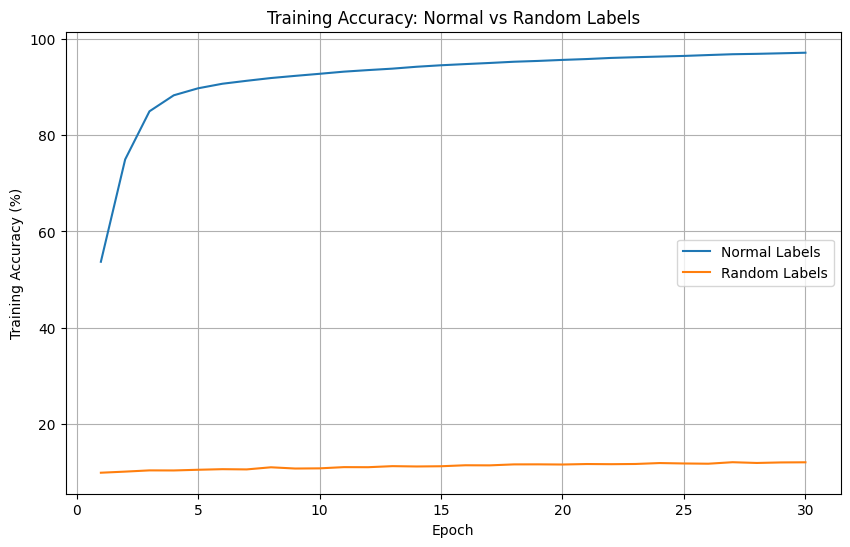

In [ ]:
plt.figure(figsize=(10, 6))

for experiment in results["experiment"].unique():

    data = results[
        results["experiment"] == experiment
    ]

    plt.plot(
        data["epoch"],
        data["train_accuracy"],
        label=experiment
    )

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.title("Training Accuracy: Normal vs Random Labels")
plt.legend()
plt.grid(True)

plt.show()


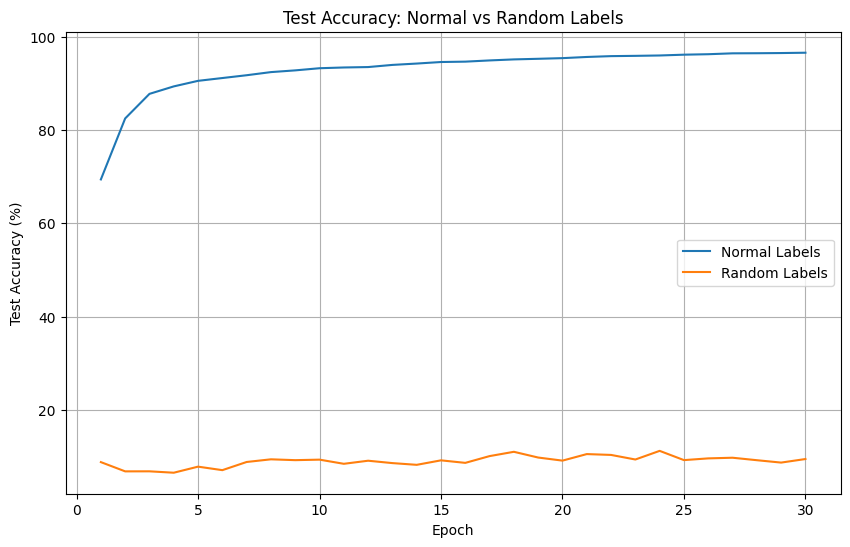

In [ ]:
plt.figure(figsize=(10, 6))

for experiment in results["experiment"].unique():

    data = results[
        results["experiment"] == experiment
    ]

    plt.plot(
        data["epoch"],
        data["test_accuracy"],
        label=experiment
    )

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy: Normal vs Random Labels")
plt.legend()
plt.grid(True)

plt.show()

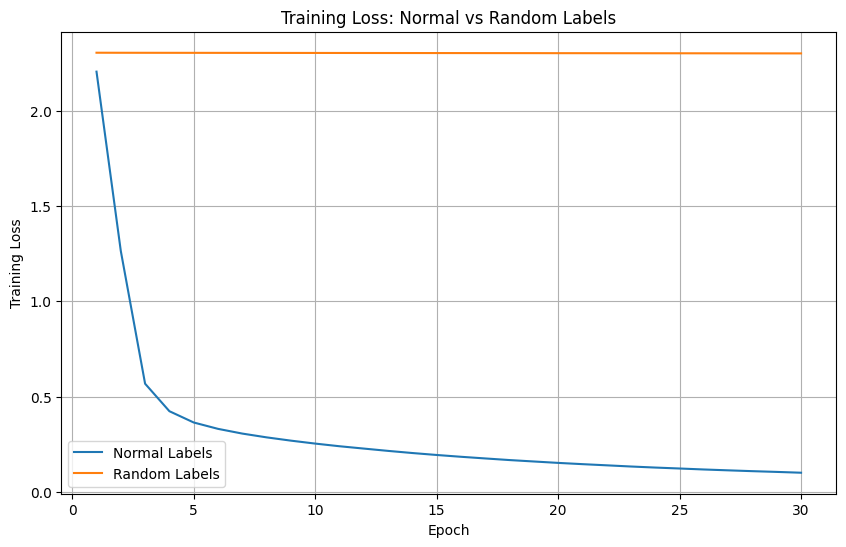

In [ ]:
plt.figure(figsize=(10, 6))

for experiment in results["experiment"].unique():

    data = results[
        results["experiment"] == experiment
    ]

    plt.plot(
        data["epoch"],
        data["train_loss"],
        label=experiment
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: Normal vs Random Labels")
plt.legend()
plt.grid(True)

plt.show()

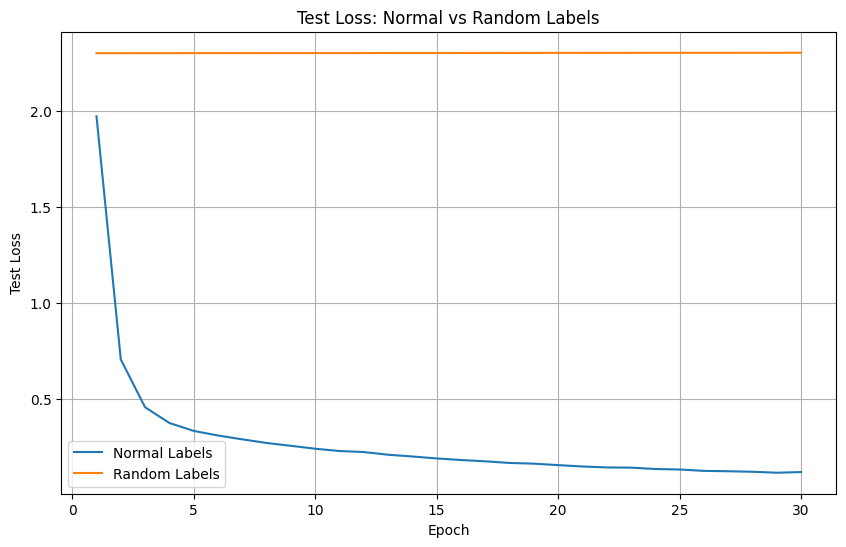

In [ ]:
plt.figure(figsize=(10, 6))

for experiment in results["experiment"].unique():

    data = results[
        results["experiment"] == experiment
    ]

    plt.plot(
        data["epoch"],
        data["test_loss"],
        label=experiment
    )

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss: Normal vs Random Labels")
plt.legend()
plt.grid(True)

plt.show()

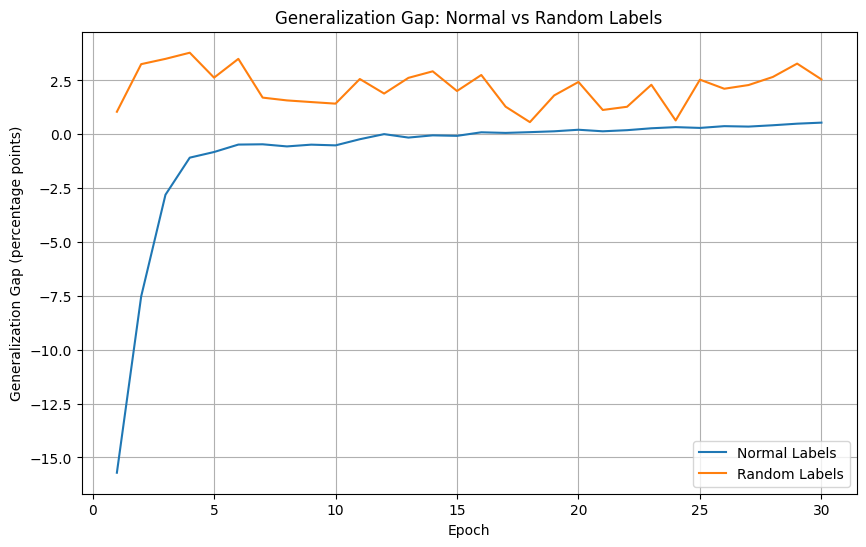

In [ ]:
plt.figure(figsize=(10, 6))

for experiment in results["experiment"].unique():

    data = results[
        results["experiment"] == experiment
    ]

    plt.plot(
        data["epoch"],
        data["generalization_gap"],
        label=experiment
    )

plt.xlabel("Epoch")
plt.ylabel("Generalization Gap (percentage points)")
plt.title("Generalization Gap: Normal vs Random Labels")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
results.to_csv(
    "experiment_3_memorization_results.csv",
    index=False
)

final_results.to_csv(
    "experiment_3_memorization_final_results.csv",
    index=False
)

print("\nResults saved:")
print("experiment_3_memorization_results.csv")
print("experiment_3_memorization_final_results.csv")


Results saved:
experiment_3_memorization_results.csv
experiment_3_memorization_final_results.csv


### Conclusion

The model achieved 97.08% training accuracy on normal labels but only 12.09% on random labels, remaining close to chance level.

Thus, the network did not memorize random labels under the tested SGD configuration, despite having approximately 10 million parameters.